In [1]:
import pandas as pd

# prevent false warning
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
pd.options.mode.chained_assignment = None  # default='warn'

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import openpyxl # needed for pd to read excel

import math
import re
import datetime
import glob

In [2]:
df_in = pd.read_excel('OSV permits 1 Apr 2018 - 30 March 2020_B.xlsx', header=None, usecols=[0, 2, 3, 4, 6], 
                    names=['gate', 'date', 'permit', 'fee_category', 'guest_count'],
                   skiprows=6)

# remove totoal sum row
df_in.drop(df_in.tail(1).index, inplace=True)

In [3]:
df_in.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 178538 entries, 0 to 178537
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   gate          178538 non-null  object        
 1   date          178538 non-null  datetime64[ns]
 2   permit        178538 non-null  float64       
 3   fee_category  178538 non-null  object        
 4   guest_count   178538 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 8.2+ MB


In [152]:
df_in.to_csv('osv_permits.csv', index=False)

In [4]:
df_in.gate.unique()

array(['BERG-EN-DAL REST CAMP', 'CROCODILE BRIDGE GATE',
       'CROCODILE BRIDGE REST CAMP', 'KRUGER GATE', 'MALELANE GATE',
       'MALELANE REST CAMP', 'NUMBI GATE', 'ORPEN GATE',
       'ORPEN REST CAMP', 'PAFURI GATE', 'PHABENI GATE',
       'PHALABORWA GATE', 'PRETORIUSKOP REST CAMP', 'PUNDA MARIA GATE',
       'SKUKUZA AIRPORT', 'SKUKUZA REST CAMP'], dtype=object)

In [30]:
# cleanup small and unimportant camps
df = df_in

# merge all permits from CROCODILE BRIDGE CAMP to it's GATE
df.loc[df['gate'] == 'CROCODILE BRIDGE REST CAMP', 'gate'] = 'CROCODILE BRIDGE GATE'

# merge all permits from ORPEN REST CAMP to it's GATE
df.loc[df['gate'] == 'ORPEN REST CAMP', 'gate'] = 'ORPEN GATE'

# remove all remaining CAMPs
#df = df[~df.gate.str.contains('CAMP')]
#df = df[~df.gate.str.contains('AIRPORT')]

In [7]:
df.gate.unique()

array(['CROCODILE BRIDGE GATE', 'KRUGER GATE', 'MALELANE GATE',
       'NUMBI GATE', 'ORPEN GATE', 'PAFURI GATE', 'PHABENI GATE',
       'PHALABORWA GATE', 'PUNDA MARIA GATE'], dtype=object)

# OSVs (permits) per gate

In [31]:
gp1 = df.groupby(['permit', 'gate', 'date']).sum(['guest_count'])

In [32]:
gp2 = gp1.groupby(['gate']).size().reset_index(name='count_osvs')

In [33]:
gp2

,gate,count_osvs
0,BERG-EN-DAL REST CAMP,3
1,CROCODILE BRIDGE GATE,10352
2,KRUGER GATE,11379
3,MALELANE GATE,11709
4,MALELANE REST CAMP,2
5,NUMBI GATE,22622
6,ORPEN GATE,10140
7,PAFURI GATE,3
8,PHABENI GATE,25269
9,PHALABORWA GATE,2877


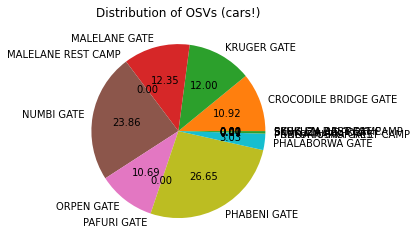

In [34]:
gp2['count_osvs'].plot.pie(autopct='%.2f', labels=gp2['gate'])
plt.title('Distribution of OSVs (cars!)')
plt.ylabel('')
plt.show()

In [12]:
gp3 = gp1.groupby(['gate']).sum(['guest_count'])

In [13]:
gp3

,guest_count
gate,
CROCODILE BRIDGE GATE,56240
KRUGER GATE,55700
MALELANE GATE,76834
NUMBI GATE,174032
ORPEN GATE,65499
PAFURI GATE,8
PHABENI GATE,164249
PHALABORWA GATE,15068
PUNDA MARIA GATE,10


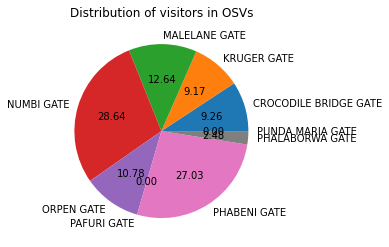

In [14]:
gp3['guest_count'].plot.pie(autopct='%.2f', labels=gp2['gate'])
plt.title('Distribution of visitors in OSVs')
plt.ylabel('')
plt.show()

# Identify Cars (OSVs) per Gate/Hour

In [15]:
gp = df.groupby(['permit', 'gate', 'date']).sum(['guest_count'])

In [16]:
df2 = gp.reset_index()

In [17]:
df2.head()

,permit,gate,date,guest_count
0,8989017.0,NUMBI GATE,2018-04-01 05:38:02.670,10
1,8989018.0,NUMBI GATE,2018-04-01 05:39:15.960,10
2,8989020.0,NUMBI GATE,2018-04-01 05:40:09.230,10
3,8989021.0,NUMBI GATE,2018-04-01 05:41:09.977,10
4,8989022.0,NUMBI GATE,2018-04-01 05:42:00.350,9


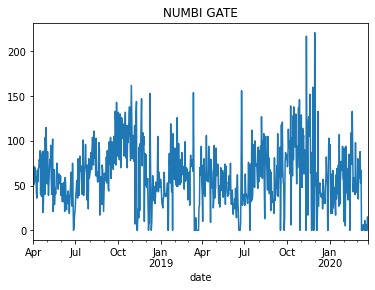

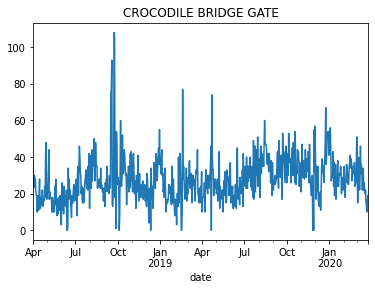

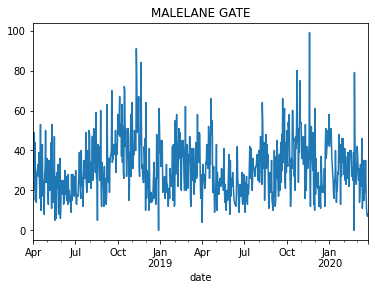

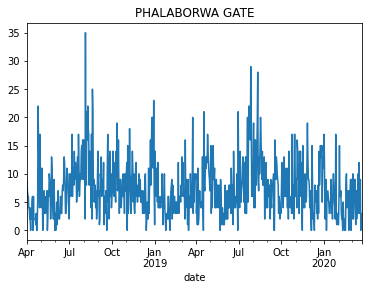

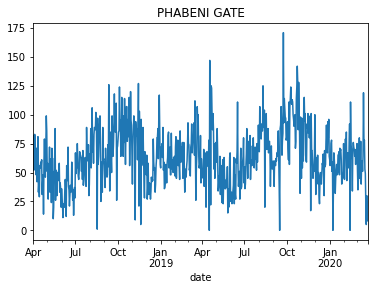

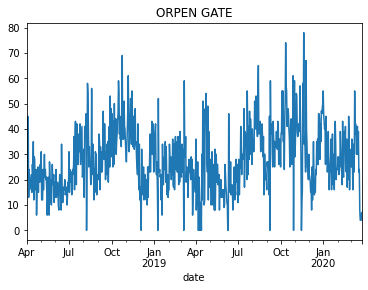

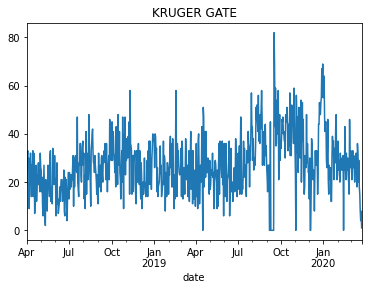

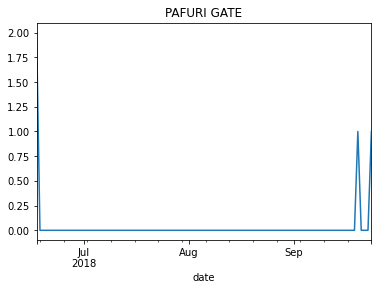

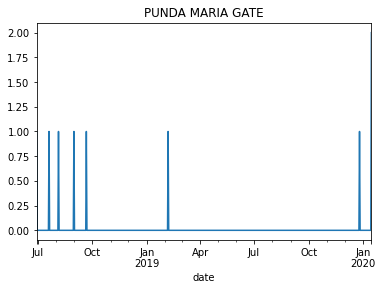

In [18]:
gates = list(df2.gate.unique())

for g in gates:
    dfx = df[df['gate'] == g] # filter for single gate

    gpx = dfx.resample('D', on='date').permit.count()
    
    gpx.plot()
    plt.title(g)
    plt.show()

In [19]:
gates = list(df2.gate.unique())

osvs_per_gate_hour = []

for g in gates:
    dfx = df2[df2['gate'] == g] # filter for single gate
    gpx = dfx.resample('H', on='date').permit.count()
    
    dft = gpx.reset_index()
    dft['hour'] = pd.DatetimeIndex(dft['date']).hour

    #dft = dft[dft.permit != 0]
    
    row = {'name': g}
    
    for h in range(24):
        dfxx = dft[dft['hour'] == h]    
        
        #print(h, dfxx.permit.mean())
        
        row["h"+str(h)] = dfxx.permit.mean()

        #dfxx.boxplot(column='permit')
        #plt.show()
        
    osvs_per_gate_hour.append(row)
    
    #gpx.plot()
    #plt.title(g)
    #plt.show()

In [20]:
dfhours = pd.DataFrame(osvs_per_gate_hour)

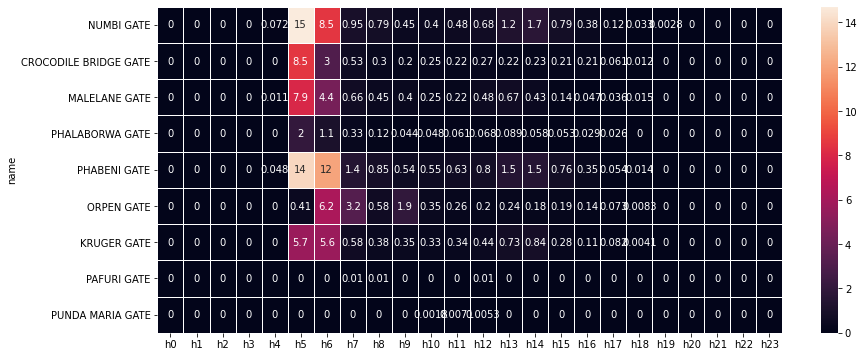

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))         # Sample figsize in inches

sns.heatmap(dfhours.set_index('name'), linewidth=.5, annot=True, ax=ax)
plt.show()

# Scheduler CSV

Example:

```
startTime,endTime,spawningIntervalInMinutes,spawningAmount,gateName,workDuration,source,destination
6:00,12:00,10,1,Phabeni Gate,10,POINT (31.240647 -25.02469),"MULTIPOINT (31.28163172149577 -25.03189838766151)"
```


In [22]:
# get gate coordinates
dfgates = pd.read_csv('../resources/pois.csv')
dfgates['Name'] = dfgates['Name'].str.upper() # make gate names UPPERCASE so we can compare straightforward

In [23]:
dfgates.loc[dfgates['Name'] == 'PHALABORWA GATE']['geometry'].values[0]

'POINT(31.1665023 -23.9457484)'

In [25]:
scheduler = []
gates = list(df2.gate.unique())

osvs_per_gate_hour = []

for g in gates:
    dfx = df2[df2['gate'] == g] # filter for single gate
    gpx = dfx.resample('H', on='date').permit.count()
    
    dft = gpx.reset_index()
    dft['hour'] = pd.DatetimeIndex(dft['date']).hour

    #dft = dft[dft.permit != 0]
    
    for h in range(24):
        dfxx = dft[dft['hour'] == h]    
        mean = dfxx.permit.mean()
        date = pd.to_datetime(str(dfxx['date'].values[0]))
        date_end = date + datetime.timedelta(minutes=59)
        
        if mean > 1:
            osvs = 60 / mean
            probability = 1
        else:
            osvs = 59
            probability = mean
        
        if mean == 0:
            continue;

        
        scheduler.append({
            'startTime': date.strftime('%-H:%M'),
            'endTime': date_end.strftime('%-H:%M'),
            'spawningIntervalInMinutes': int(osvs),
            'spawningAmount': 1,
            'spawningProbability': probability,
            'gateName': g,
            'source': dfgates.loc[dfgates['Name'] == g]['geometry'].values[0],
            'destination': '' # no destionation needed, since OSVs leave by same gate and just drive random?
        })

In [26]:
df_scheduler = pd.DataFrame(scheduler)
df_scheduler.head(30)
df_scheduler.to_csv('../resources/osvScheduler.csv', index=False)

# sanity check to look how many ppl per car

In [27]:
gp = df.groupby(['permit']).sum(['guest_count'])

In [28]:
gp

,guest_count
permit,
8989017.0,10
8989018.0,10
8989020.0,10
8989021.0,10
8989022.0,9
...,...
10704715.0,1
10704717.0,1
10704753.0,2


<AxesSubplot:>

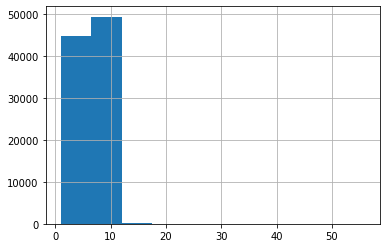

In [29]:
gp['guest_count'].hist()